<a href="https://colab.research.google.com/github/ivanduzunov/AI-Agents-and-Workflows-for-Developers/blob/main/LongTermShortTermMemory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q langchain langchain-openai langchain-community langchain-chroma langchain-text-splitters

In [34]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI
from langchain.messages import AIMessage, HumanMessage, SystemMessage
from langchain_core.messages import BaseMessage
from langchain_core.tools import create_retriever_tool
from langchain_community.document_loaders import TextLoader
from langchain.tools import tool
from langchain.agents.middleware.types import after_model, before_model
from langchain.agents import AgentState
from langgraph.runtime import Runtime
from google.colab import userdata
from pydantic import SecretStr
from typing import List
from IPython.display import Image
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
import json

In [4]:

def print_conversation(messages: List[BaseMessage]):
  for message in messages:
    message.pretty_print()

In [62]:
model = ChatOpenAI(model="gpt-5-nano", api_key=userdata.get('OPENAI_KEY'))

In [63]:
checkpointer = InMemorySaver()

In [64]:
@before_model
def before_model_func(state: AgentState, runtime: Runtime):
  print("BEFORE MODEL FUNC")

@after_model
def after_model_func(state: AgentState, runtime: Runtime):
  print("AFTER MODEL FUNC")

In [65]:
agent = create_agent(
    model=model,
    checkpointer=checkpointer,
    tools=[],
    middleware=[before_model_func, after_model_func],
    system_prompt="You are helpful personal assistant",
    debug=True
)

In [ ]:
response_1 = agent.invoke(
    input={
      "messages": [
          HumanMessage(content="Hello, my name is Ivan Uzunov.")
      ]
    },
    config={
      "configurable": {
          "thread_id": "thread_id_1"
      }
    }
  )

In [ ]:
response_2 = agent.invoke(
    input={
      "messages": [
          HumanMessage(content="Do you know my name?")
      ]
  },
  config={
      "configurable": {
          "thread_id": "thread_id_1"
      }
    }
)

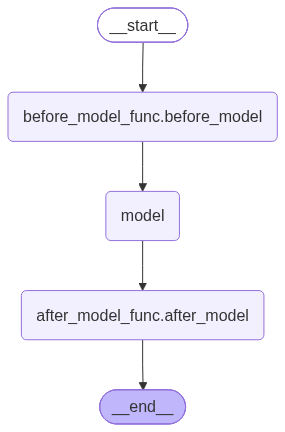

In [40]:
display(Image(agent.get_graph().draw_mermaid_png()))


In [ ]:
for x in checkpointer.list({"configurable": {"thread_id": "thread_id_1"}}):
  print(x)